In [1]:
# =========================
# 1) Imports & Config
# =========================
import os, math
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import joblib

SEED = 42
BATCH_SIZE = 32
EPOCHS = 60
MODEL_DIR = "ser_cnn_bilstm_logmel"
os.makedirs(MODEL_DIR, exist_ok=True)
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
# =========================
# 2) Load data
# =========================
data_folder = "../../datasets_log_mel_combined"

X_train = np.load(f"{data_folder}/X_logmel_train.npy")   # (N_train, T, 128)
y_train = np.load(f"{data_folder}/y_logmel_train.npy")   # (N_train,)
X_val   = np.load(f"{data_folder}/X_logmel_val.npy")
y_val   = np.load(f"{data_folder}/y_logmel_val.npy")
X_test  = np.load(f"{data_folder}/X_logmel_test.npy")
y_test  = np.load(f"{data_folder}/y_logmel_test.npy")

In [3]:
# =========================
# 3) Label encoding & class weights
# =========================
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)
y_val_int   = le.transform(y_val)
y_test_int  = le.transform(y_test)
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# Save label encoder for later inference
joblib.dump(le, "label_encoder.joblib")

# Class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_int
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Class weights: {0: np.float64(0.9381882249302599), 1: np.float64(0.901142293047525), 2: np.float64(0.9029249682068673), 3: np.float64(0.901142293047525), 4: np.float64(0.9020327498588369), 5: np.float64(0.901142293047525), 6: np.float64(2.5714285714285716)}


In [4]:
# =========================
# 4) tf.data Pipelines + SpecAugment
#     We augment ONLY training batches.
# =========================

def add_channel(x):
    # From (T, 128) -> (T, 128, 1) for Conv2D
    x = tf.expand_dims(x, axis=-1)
    return x

@tf.function
def specaugment(x, y,
                max_freq_mask=24,  # up to 24 mel bins
                max_time_mask=32,  # up to 32 frames
                num_freq_masks=2,
                num_time_masks=2):
    """
    x: (T, 128, 1) log-mel; apply frequency & time masking (SpecAugment).
    """
    T = tf.shape(x)[0]
    F = tf.shape(x)[1]

    # Frequency masks
    for _ in range(num_freq_masks):
        f = tf.random.uniform([], minval=0, maxval=max_freq_mask+1, dtype=tf.int32)
        f0 = tf.random.uniform([], minval=0, maxval=tf.maximum(1, F - f), dtype=tf.int32)
        mask = tf.concat([
            tf.ones((T, f0, 1), dtype=x.dtype),
            tf.zeros((T, f, 1), dtype=x.dtype),
            tf.ones((T, F - f0 - f, 1), dtype=x.dtype)
        ], axis=1)
        x = x * mask

    # Time masks
    for _ in range(num_time_masks):
        t = tf.random.uniform([], minval=0, maxval=max_time_mask+1, dtype=tf.int32)
        t0 = tf.random.uniform([], minval=0, maxval=tf.maximum(1, T - t), dtype=tf.int32)
        mask = tf.concat([
            tf.ones((t0, F, 1), dtype=x.dtype),
            tf.zeros((t, F, 1), dtype=x.dtype),
            tf.ones((T - t0 - t, F, 1), dtype=x.dtype)
        ], axis=0)
        x = x * mask

    return x, y

def ds_from_arrays(X, y_int, batch_size, training=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y_int))
    if training and shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 2048), seed=SEED, reshuffle_each_iteration=True)
    # map to (T, 128, 1)
    ds = ds.map(lambda x, y: (add_channel(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        # Apply SpecAugment with probability ~0.8
        def maybe_augment(x, y):
            do_aug = tf.less(tf.random.uniform([], 0, 1.0), 0.8)
            x, y = tf.cond(do_aug, lambda: specaugment(x, y), lambda: (x, y))
            return x, y
        ds = ds.map(maybe_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = ds_from_arrays(X_train, y_train_int, BATCH_SIZE, training=True)
val_ds   = ds_from_arrays(X_val,   y_val_int,   BATCH_SIZE, training=False, shuffle=False)
test_ds  = ds_from_arrays(X_test,  y_test_int,  BATCH_SIZE, training=False, shuffle=False)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers as L, models

# --- input: (time_steps, 128 mel bins)
input_shape = (X_train.shape[1], X_train.shape[2])

model = models.Sequential([
    # --- CNN Block 1 ---
    L.Conv1D(128, kernel_size=5, padding='same', activation='relu', input_shape=input_shape),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, padding='same'),

    # --- CNN Block 2 ---
    L.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, padding='same'),
    L.Dropout(0.1),

    # --- CNN Block 3 ---
    L.Conv1D(256, kernel_size=3, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, padding='same'),
    L.Dropout(0.1),

    # --- BiLSTM Block ---
    L.Bidirectional(L.LSTM(128, return_sequences=False)),
    L.Dropout(0.2),

    # --- Dense Layers ---
    L.Dense(256, activation='relu'),
    L.Dropout(0.2),
    L.Dense(128, activation='relu'),

    # --- Output ---
    L.Dense(num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',  # use sparse labels (ints)
    metrics=['accuracy']
)

model.summary()


c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 435, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 435, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 218, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 218, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 218, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 109, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 109, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 109, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 109, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 55, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 55, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 725,767 (2.77 MB)

 Trainable params: 724,743 (2.76 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ModelCheckpoint('log_mel_cnn_lstm.keras', save_best_only=True, monitor='val_accuracy')
]

history = model.fit(
    X_train, y_train_int,
    validation_data=(X_val, y_val_int),
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict,   # optional
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 213ms/step - accuracy: 0.2460 - loss: 1.7455 - val_accuracy: 0.2042 - val_loss: 1.8254
Epoch 2/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 188ms/step - accuracy: 0.3698 - loss: 1.4468 - val_accuracy: 0.1986 - val_loss: 2.7117
Epoch 3/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.4548 - loss: 1.2838 - val_accuracy: 0.2451 - val_loss: 2.7135
Epoch 4/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 182ms/step - accuracy: 0.4915 - loss: 1.1907 - val_accuracy: 0.3746 - val_loss: 1.6161
Epoch 5/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.5279 - loss: 1.1223 - val_accuracy: 0.3474 - val_loss: 1.8092
Epoch 6/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 35s 175ms/step - accuracy: 0.5427 - loss: 1.0779 - val_accuracy: 0.4972 - val_loss: 1.2771
Epoch 7/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 193ms/step - accuracy: 0.5509 - loss: 1.0555 - val_accuracy: 0.4995 - val_loss: 1.3210
Epoch 8/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 190ms/step - accuracy: 0.5582 - loss: 1

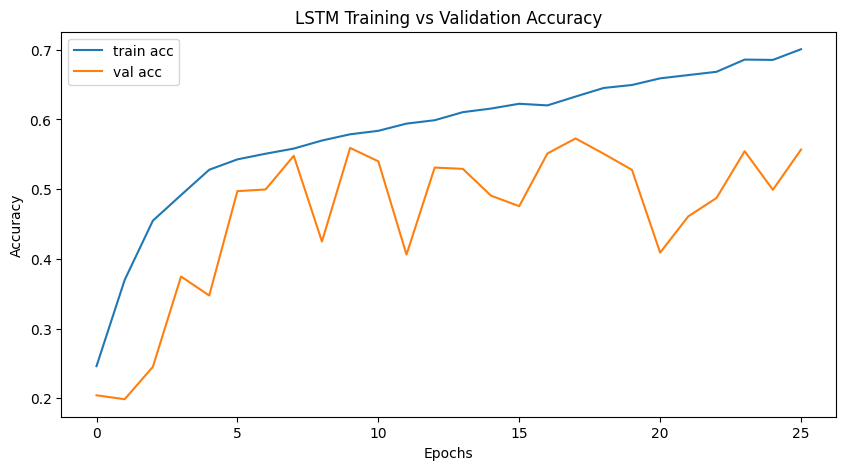

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Training vs Validation Accuracy')
plt.show()

### Evaluate Model

In [8]:
from tensorflow.keras.models import load_model

# Load model
best_model = load_model('log_mel_best_cnn_lstm.keras')


In [10]:
test_loss, test_acc = best_model.evaluate(X_test, y_test_int, verbose=1)
print(f"Test Accuracy: {test_acc:.3f}, Test Loss: {test_loss:.3f}")


67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.5906 - loss: 1.0803
Test Accuracy: 0.591, Test Loss: 1.080


In [11]:
best_val_acc = max(history.history['val_accuracy'])
print("Best Val Accuracy:", best_val_acc)


Best Val Accuracy: 0.5727699398994446
